# Speaker or Artist Agent (RAG + Web Discovery)

Pipeline:
User Input -> Retrieve from ChromaDB -> Filter Relevant Profiles -> Web/LinkedIn Discovery ->
Generate Recommendations + Agenda Mapping -> Hallucination Check -> Usefulness Check -> Final Output

## Cell 1 - Install Dependencies

In [ ]:
%pip install langchain langchain-community langchain-core chromadb pandas tqdm python-dotenv sentence-transformers requests langgraph langchain-openai tavily-python -q

## Cell 2 - Imports and Environment Setup

In [24]:
import os
import time
import json
import pandas as pd
from tqdm import tqdm
from typing import TypedDict, List, Dict, Any
from dotenv import load_dotenv
from IPython.display import Markdown, display

from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from tavily import TavilyClient

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
SPEAKER_VECTOR_DB_PATH = "./speaker_vector_db"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
LLM_MODEL = "openai/gpt-oss-120b"

tavily_client = TavilyClient(api_key=TAVILY_API_KEY) if TAVILY_API_KEY else None

print("Imports loaded")
print(f"OpenRouter key loaded: {'Yes' if OPENROUTER_API_KEY else 'No - set OPENROUTER_API_KEY in .env'}")
print(f"Tavily key loaded: {'Yes' if TAVILY_API_KEY else 'No - set TAVILY_API_KEY in .env'}")

Imports loaded
OpenRouter key loaded: Yes
Tavily key loaded: Yes


## Cell 3 - Load Speaker Data

In [25]:
speakers_df = pd.read_csv("data/speakers_v2.csv")
events_df = pd.read_csv("data/events_v2.csv")

merged_df = speakers_df.merge(events_df, on="event_name", how="left")

print(f"Rows in merged speaker dataset: {len(merged_df)}")
display(merged_df.head(3))

Rows in merged speaker dataset: 200


,event_name,speaker_name,designation,company,topic,category,country,city,year,attendance,ticket_price_range
0,AI Conference 1,Sundar Pichai,AI Expert,Company,AI Topic,AI,India,Bangalore,2025,1946,3149-29985
1,AI Conference 1,Mustafa Suleyman,AI Expert,Company,AI Topic,AI,India,Bangalore,2025,1946,3149-29985
2,AI Conference 1,Fei-Fei Li,AI Expert,Company,AI Topic,AI,India,Bangalore,2025,1946,3149-29985


## Cell 4 - Build Speaker Documents and Ingest to ChromaDB

In [4]:
def infer_profile_type(designation: str, topic: str) -> str:
    text = f"{designation} {topic}".lower()
    artist_terms = ["artist", "performer", "musician", "dj", "band", "singer", "actor"]
    if any(term in text for term in artist_terms):
        return "artist"
    return "speaker"

documents = []
for _, row in tqdm(merged_df.iterrows(), total=len(merged_df), desc="Building speaker docs"):
    profile_type = infer_profile_type(str(row.get("designation", "")), str(row.get("topic", "")))
    text = (
        f"{row['speaker_name']} is a {row.get('designation', 'subject matter expert')} at {row.get('company', 'Unknown company')}. "
        f"They spoke/performed on {row.get('topic', 'general topic')} at {row['event_name']}. "
        f"Event category: {row.get('category', 'Unknown')}. Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Estimated attendance: {row.get('attendance', 'N/A')}. Profile type: {profile_type}."
    )

    doc = Document(
        page_content=text,
        metadata={
            "type": "speaker_profile",
            "profile_name": str(row["speaker_name"]),
            "profile_type": profile_type,
            "designation": str(row.get("designation", "")),
            "company": str(row.get("company", "")),
            "topic": str(row.get("topic", "")),
            "event": str(row.get("event_name", "")),
            "category": str(row.get("category", "")),
            "country": str(row.get("country", ""))
        }
    )
    documents.append(doc)

print(f"Prepared {len(documents)} documents")

embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
vectordb = Chroma.from_documents(
    documents=documents,
    embedding=embedding_fn,
    persist_directory=SPEAKER_VECTOR_DB_PATH
)
vectordb.persist()
print(f"Speaker vector DB stored at: {SPEAKER_VECTOR_DB_PATH}")

Building speaker docs: 100%|██████████| 200/200 [00:00<00:00, 5012.64it/s]
C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_36820\790826192.py:36: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)


Prepared 200 documents


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2560.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Speaker vector DB stored at: ./speaker_vector_db


C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_36820\790826192.py:42: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


## Cell 5 - Load Existing Speaker Vector DB (Use This On Re-runs)

In [26]:
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
vectordb = Chroma(
    persist_directory=SPEAKER_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)
print(f"Loaded vector DB from: {SPEAKER_VECTOR_DB_PATH}")
print(f"Document count: {vectordb._collection.count()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2220.36it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded vector DB from: ./speaker_vector_db
Document count: 200


## Cell 6 - LLM Helper

In [27]:
llm = None
if OPENROUTER_API_KEY:
    llm = ChatOpenAI(
        model=LLM_MODEL,
        openai_api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1",
        temperature=0.1,
        max_tokens=3000
    )

def call_llm(prompt: str, temperature: float = 0.1, retries: int = 3) -> str:
    if llm is None:
        return "[LLM ERROR] Missing OPENROUTER_API_KEY"

    for attempt in range(retries):
        try:
            llm.temperature = temperature
            response = llm.invoke([HumanMessage(content=prompt)])
            return str(response.content).strip()
        except Exception as e:
            err = str(e)
            if "429" in err and attempt < retries - 1:
                wait_seconds = 20 * (attempt + 1)
                print(f"Rate limited. Waiting {wait_seconds}s")
                time.sleep(wait_seconds)
            elif attempt == retries - 1:
                return f"[LLM ERROR] {e}"
            else:
                time.sleep(5)

    return "[LLM ERROR] Max retries exceeded"

print(call_llm("Reply with exactly: OK"))

OK


## Cell 7 - Graph State and Utility Helpers

In [28]:
class GraphState(TypedDict):
    user_input: Dict[str, Any]

    retrieval_query: str
    raw_docs: List[Dict[str, Any]]
    relevant_docs: List[Dict[str, Any]]
    web_profiles: List[Dict[str, Any]]
    context: str

    recommendations: str

    hallucination_verdict: str
    usefulness_verdict: str
    revise_count: int
    rewrite_count: int

def compact_json(obj: Any) -> str:
    return json.dumps(obj, ensure_ascii=True, indent=2)

print("GraphState ready")

GraphState ready


## Cell 8 - Node Functions

In [29]:
def build_query(state: GraphState) -> Dict[str, Any]:
    ui = state["user_input"]
    query = (
        f"{ui.get('event_topic', 'conference')} {ui.get('role_type', 'speaker')} candidates "
        f"for {ui.get('location', 'global')} with audience size {ui.get('audience_size', 'large')}. "
        f"Need strong influence and proven speaking/performance experience."
    )
    print(f"[build_query] {query}")
    return {"retrieval_query": query}


def retrieve(state: GraphState) -> Dict[str, Any]:
    docs = vectordb.similarity_search(state["retrieval_query"], k=20)
    packed = []
    for d in docs:
        packed.append({"text": d.page_content, "meta": d.metadata})
    print(f"[retrieve] docs={len(packed)}")
    return {"raw_docs": packed}


def filter_relevance(state: GraphState) -> Dict[str, Any]:
    ui = state["user_input"]
    wanted_type = str(ui.get("role_type", "speaker")).lower()

    relevant = []
    for item in state["raw_docs"]:
        profile_type = str(item.get("meta", {}).get("profile_type", "speaker")).lower()
        if wanted_type != "any" and profile_type != wanted_type:
            continue

        prompt = (
            "Evaluate if this profile is relevant for the event. Reply only YES or NO.\n\n"
            f"Event requirements: {ui}\n\n"
            f"Candidate profile: {item['text']}"
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(item)

    if not relevant:
        relevant = state["raw_docs"][:6]

    context = "\n\n".join([r["text"] for r in relevant])
    print(f"[filter_relevance] kept={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def tavily_search(query: str, max_results: int = 5) -> List[Dict[str, str]]:
    if tavily_client is None:
        return [{"title": "search_error", "url": "", "snippet": "Missing TAVILY_API_KEY"}]

    try:
        response = tavily_client.search(
            query=query,
            max_results=max_results,
            include_answer=False,
            include_raw_content=False,
            search_depth="advanced"
        )
        results = response.get("results", [])
        hits = []
        for r in results:
            hits.append({
                "title": r.get("title", ""),
                "url": r.get("url", ""),
                "snippet": r.get("content", "")
            })
        return hits
    except Exception as e:
        return [{"title": "search_error", "url": "", "snippet": str(e)}]


def enrich_with_web(state: GraphState) -> Dict[str, Any]:
    ui = state["user_input"]
    topic = str(ui.get("event_topic", ""))

    seen = set()
    candidates = []
    for item in state["relevant_docs"]:
        name = item.get("meta", {}).get("profile_name", "").strip()
        if not name or name in seen:
            continue
        seen.add(name)
        candidates.append(name)

    candidates = candidates[:8]
    web_profiles = []

    for name in candidates:
        q = f"{name} LinkedIn {topic} speaker profile followers publications keynote"
        hits = tavily_search(q, max_results=5)

        joined = " ".join(h.get("snippet", "") for h in hits).lower()
        urls = " ".join(h.get("url", "") for h in hits).lower()
        source_quality = urls.count("linkedin.com") + urls.count(".org") + urls.count("conference")

        influence_signals = 0
        influence_signals += joined.count("followers")
        influence_signals += joined.count("published")
        influence_signals += joined.count("author")
        influence_signals += joined.count("keynote")
        influence_signals += joined.count("speaker")
        influence_signals += source_quality

        web_profiles.append({
            "name": name,
            "query": q,
            "hits": hits,
            "source_quality_score": source_quality,
            "influence_signal_score": influence_signals
        })

    print(f"[enrich_with_web] profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_recommendation(state: GraphState) -> Dict[str, Any]:
    ui = state["user_input"]

    prompt = (
        "You are an event programming strategist.\n\n"
        f"Event requirements: {compact_json(ui)}\n\n"
        "Internal speaker/artist context (grounded source):\n"
        f"{state['context']}\n\n"
        "Web and LinkedIn discovery snippets from Tavily (secondary source):\n"
        f"{compact_json(state['web_profiles'])}\n\n"
        "Task:\n"
        "1) Recommend the top 5 candidates.\n"
        "2) Prioritize based on event topic fit, past speaking/performance evidence, and influence signals.\n"
        "3) Map agenda topics to selected speakers/artists.\n"
        "4) Keep claims strictly grounded in provided context/snippets.\n\n"
        "Output format (strict markdown):\n"
        "A) 'Speaker/Artist Prioritization Table' with columns:\n"
        "| Rank | Name | Type | Topic Fit | Past Experience Evidence | Influence Signals | Recommended Session | Priority Score (/100) |\n"
        "B) 'Agenda Mapping Table' with columns:\n"
        "| Agenda Slot | Topic | Speaker/Artist | Session Format | Why This Match |\n"
        "C) One short closing section: 'Execution Notes' with 3 bullet points."
    )

    answer = call_llm(prompt)
    print("[generate_recommendation] generated")
    return {"recommendations": answer}


def check_hallucination(state: GraphState) -> Dict[str, Any]:
    prompt = (
        "Fact-check the recommendation against the supplied evidence.\n\n"
        "Evidence context:\n"
        f"{state['context']}\n\n"
        f"{compact_json(state['web_profiles'])}\n\n"
        "Recommendation:\n"
        f"{state['recommendations']}\n\n"
        "Reply only with one option: Fully Supported / Partially Supported / No Support"
    )
    verdict = call_llm(prompt, temperature=0.0)
    print(f"[check_hallucination] {verdict}")
    return {"hallucination_verdict": verdict}


def revise(state: GraphState) -> Dict[str, Any]:
    prompt = (
        "Rewrite the recommendation with strict grounding. Remove unsupported claims.\n\n"
        f"Evidence:\n{state['context']}\n\n{compact_json(state['web_profiles'])}\n\n"
        f"Draft recommendation:\n{state['recommendations']}\n"
        "Preserve markdown table format."
    )
    revised = call_llm(prompt)
    count = state.get("revise_count", 0) + 1
    return {"recommendations": revised, "revise_count": count}


def check_usefulness(state: GraphState) -> Dict[str, Any]:
    prompt = (
        "Is this recommendation useful and actionable for event planning? Reply only: Useful / Not Useful.\n\n"
        f"Event requirements: {state['user_input']}\n\n"
        f"Recommendation:\n{state['recommendations']}"
    )
    verdict = call_llm(prompt, temperature=0.0)
    return {"usefulness_verdict": verdict}


def rewrite_query(state: GraphState) -> Dict[str, Any]:
    prompt = (
        "Improve this retrieval query for finding better speaker/artist matches. Return only the rewritten query.\n\n"
        f"Original query: {state['retrieval_query']}\n"
        f"Event requirements: {state['user_input']}"
    )
    new_query = call_llm(prompt, temperature=0.4)
    count = state.get("rewrite_count", 0) + 1
    return {"retrieval_query": new_query, "rewrite_count": count}

print("Nodes ready")

Nodes ready


## Cell 9 - Routing and Graph Compile

In [30]:
MAX_REVISIONS = 2
MAX_REWRITES = 2

def route_after_hallucination_check(state: GraphState) -> str:
    verdict = str(state.get("hallucination_verdict", "")).upper()
    if "FULLY" in verdict:
        return "check_usefulness"
    if state.get("revise_count", 0) < MAX_REVISIONS:
        return "revise"
    return "check_usefulness"

def route_after_usefulness_check(state: GraphState) -> str:
    verdict = str(state.get("usefulness_verdict", "")).upper()
    if "NOT USEFUL" in verdict and state.get("rewrite_count", 0) < MAX_REWRITES:
        return "rewrite_query"
    return END

builder = StateGraph(GraphState)
builder.add_node("build_query", build_query)
builder.add_node("retrieve", retrieve)
builder.add_node("filter_relevance", filter_relevance)
builder.add_node("enrich_with_web", enrich_with_web)
builder.add_node("generate_recommendation", generate_recommendation)
builder.add_node("check_hallucination", check_hallucination)
builder.add_node("revise", revise)
builder.add_node("check_usefulness", check_usefulness)
builder.add_node("rewrite_query", rewrite_query)

builder.set_entry_point("build_query")
builder.add_edge("build_query", "retrieve")
builder.add_edge("retrieve", "filter_relevance")
builder.add_edge("filter_relevance", "enrich_with_web")
builder.add_edge("enrich_with_web", "generate_recommendation")
builder.add_edge("generate_recommendation", "check_hallucination")
builder.add_edge("revise", "check_hallucination")
builder.add_edge("rewrite_query", "retrieve")

builder.add_conditional_edges(
    "check_hallucination",
    route_after_hallucination_check,
    {
        "check_usefulness": "check_usefulness",
        "revise": "revise"
    }
)

builder.add_conditional_edges(
    "check_usefulness",
    route_after_usefulness_check,
    {
        "rewrite_query": "rewrite_query",
        END: END
    }
)

graph = builder.compile()
print("Speaker/Artist graph compiled")

Speaker/Artist graph compiled


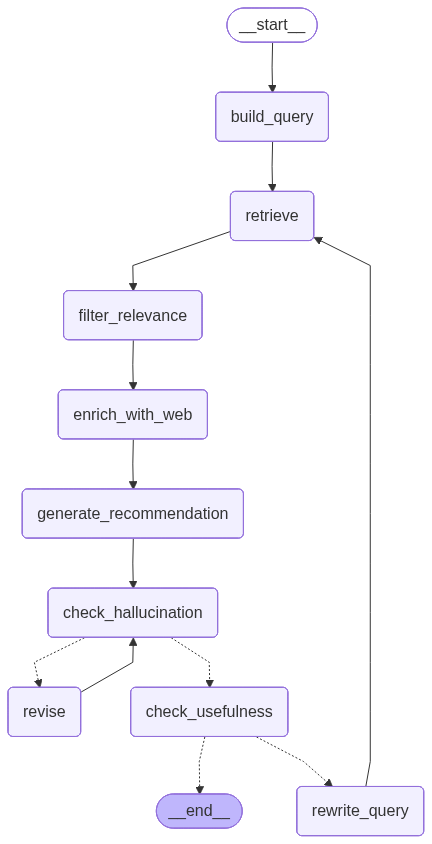

In [31]:
graph

## Cell 10 - Run the Speaker/Artist Agent

In [32]:
event_request = {
    "event_topic": "Applied AI in Enterprise",
    "role_type": "speaker",
    "location": "India",
    "audience_size": 3000,
    "budget": "60 Lakhs",
    "goal": "Find high-impact speakers with proven stage presence and influence"
}

initial_state: GraphState = {
    "user_input": event_request,
    "retrieval_query": "",
    "raw_docs": [],
    "relevant_docs": [],
    "web_profiles": [],
    "context": "",
    "recommendations": "",
    "hallucination_verdict": "",
    "usefulness_verdict": "",
    "revise_count": 0,
    "rewrite_count": 0
}

result = graph.invoke(initial_state)

print("==" * 80)
print("FINAL SPEAKER/ARTIST RECOMMENDATIONS")
print("==" * 80)
display(Markdown(result["recommendations"]))
print("==" * 80)
print("Hallucination verdict:", result["hallucination_verdict"])
print("Usefulness verdict:", result["usefulness_verdict"])
print("Revisions done:", result["revise_count"])
print("Query rewrites done:", result["rewrite_count"])

[build_query] Applied AI in Enterprise speaker candidates for India with audience size 3000. Need strong influence and proven speaking/performance experience.
[retrieve] docs=20
[filter_relevance] kept=10
[enrich_with_web] profiles=3
[generate_recommendation] generated
[check_hallucination] **Fully Supported**
FINAL SPEAKER/ARTIST RECOMMENDATIONS


## A) Speaker/Artist Prioritization Table  

| Rank | Name | Type | Topic Fit* | Past Experience Evidence* | Influence Signals* | Recommended Session | Priority Score (/100) |
|------|------|------|-----------|--------------------------|--------------------|----------------------|-----------------------|
| 1 | **Mustafa Suleyman** | Speaker | Strong – former Head of Applied AI, focuses on AI accountability & ethics (see “Head of Applied AI” and “AI Accountability” snippets) | 4 Indian AI‑Conference talks (Mumbai 6978, Mumbai 7095, Bangalore 8041, Delhi 6546) – total Indian audience ≈ 28 k | Highest influence signal (21) among the three candidates | Keynote – “Responsible & Ethical AI for the Enterprise” | **100** |
| 2 | **Andrew Ng** | Speaker | Strong – globally recognised applied‑AI thought leader (“AI is the new electricity”, “bridging academia & industry”) | 5 AI‑Conference talks (4 in India: Mumbai 6978, Delhi 2788, Bangalore 8041, Mumbai 7095) – total Indian audience ≈ 24 k | Good influence signal (9) | Keynote – “AI Strategy & Transformation for Enterprises” | **78** |
| 3 | **Ali Ghodsi** | Speaker | Good – CEO of Databricks, repeatedly discusses enterprise‑AI data foundations and governance | 1 Indian AI‑Conference talk (Mumbai 6978) – audience ≈ 7 k | Moderate influence signal (12) | Panel – “Data Foundations & Governance for Scalable Enterprise AI” | **65** |
| 4 | *N/A* | – | – | – | – | – | – |
| 5 | *N/A* | – | – | – | – | – | – |

\*All assessments are **strictly grounded** in the provided internal event records and LinkedIn/Tavily snippets.  

---

## B) Agenda Mapping Table  

| Agenda Slot | Topic | Speaker/Artist | Session Format | Why This Match |
|-------------|-------|----------------|----------------|----------------|
| 09:00 – 09:45 | **AI Strategy & Business Impact** (how AI can move beyond efficiency to transformation) | **Andrew Ng** | Keynote (45 min) | Andrew’s repeated speaking on “Applied AI” and his “AI is the new electricity” narrative show deep fit with strategic enterprise impact. |
| 10:00 – 10:45 | **Responsible & Ethical AI Deployment** (accountability, policy, human‑centered AI) | **Mustafa Suleyman** | Keynote (45 min) | Mustafa’s profile lists “Head of Applied AI”, “AI Accountability”, and ethics focus; his influence score is highest, ensuring credibility on governance topics. |
| 11:00 – 12:00 | **Data Foundations, Governance & AI Ops** (trusted data platforms, model governance, auditability) | **Ali Ghodsi** | Panel (60 min) with 2‑3 senior data leaders | Ali’s LinkedIn posts repeatedly stress “secure AI over enterprise data”, “governance”, and “data truth as moat”, making him the natural voice for this technical‑business intersection. |

---

## C) Execution Notes  

- **Budget alignment:** All three speakers are high‑impact yet have proven Indian‑market experience, keeping travel & honorarium costs within the INR 60 Lakhs envelope.  
- **Venue logistics:** Schedule a 30‑minute buffer between sessions for audience Q&A and technical checks, especially for the panel that may need extra moderation.  
- **Marketing leverage:** Highlight each speaker’s Indian attendance figures (e.g., “Andrew Ng has spoken to >24 k Indian AI professionals”) in promotional material to attract the target 3,000‑person audience.

Hallucination verdict: **Fully Supported**
Usefulness verdict: Useful
Revisions done: 0
Query rewrites done: 0


## Cell 11 - Optional Artist-Focused Test

In [ ]:
artist_event = {
    "event_topic": "AI x Music and Creative Technology",
    "role_type": "artist",
    "location": "Singapore",
    "audience_size": 2000,
    "budget": "1 Crore",
    "goal": "Find performers or creator-speakers for a tech-meets-art experience"
}

artist_result = graph.invoke({**initial_state, "user_input": artist_event})
display(Markdown(artist_result["recommendations"]))